⚠**This is a fictional dataset was created based on** [Kaggle dataset](https://www.kaggle.com/datasets/govindaramsriram/energy-consumption-dataset-linear-regression)

# **Loading the dataset**💻

In [57]:
# Import the libs
import pandas as pd
import numpy as np
# Defining the seed for reproducibility
np.random.seed(50)

# Number of rows
n = 10000

# Generating data for the columns
building_types = ['Residential', 'Commercial', 'Industrial']
building_type = np.random.choice(building_types, n)

square_footage = np.random.randint(1000, 50000, n)
num_occupants = np.random.randint(1, 101, n)
appliances_used = np.random.randint(1, 51, n)
avg_temperature = np.random.uniform(10, 35, n)
day_of_week = np.random.choice(['Weekday', 'Weekend'], n)

# Defining effects for the linear regression model
# Arbitrary coefficients based on approximate logic from the example data.
building_effect = {'Residential': 0, 'Commercial': 500, 'Industrial': 200}
day_effect = {'Weekday': 100, 'Weekend': 0}

# Calculating Energy Consumption based on a simple linear model + noise.
energy_consumption = (
    0.05 * square_footage +
    20 * num_occupants +
    30 * appliances_used +
    10 * avg_temperature +
    np.array([building_effect[bt] for bt in building_type]) +
    np.array([day_effect[dw] for dw in day_of_week]) +
    np.random.normal(0, 500, n)  # gaussian noise
)

# Ensuring positive values ​​for Energy Consumption
energy_consumption = np.maximum(energy_consumption, 0)

# Creating the dataframe
df = pd.DataFrame({
    'Building Type': building_type,
    'Square Footage': square_footage,
    'Number of Occupants': num_occupants,
    'Appliances Used': appliances_used,
    'Average Temperature': avg_temperature,
    'Day of Week': day_of_week,
    'Energy Consumption': energy_consumption
})

# Save in .csv
df.to_csv('energy_consumption.csv', index=False)

# **Preprocessing**🪓

In [58]:
# See the dataset
df

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,9484,6,33,21.000699,Weekday,1686.837613
1,Residential,27613,79,31,13.801162,Weekday,3863.167722
2,Commercial,27185,20,42,20.134371,Weekend,3989.727117
3,Commercial,9695,32,28,31.259445,Weekday,3778.305785
4,Industrial,17279,73,12,16.684112,Weekday,3608.373049
...,...,...,...,...,...,...,...
9995,Industrial,31936,70,14,10.245505,Weekday,2880.980890
9996,Industrial,29762,57,5,28.626913,Weekday,3626.018203
9997,Commercial,40775,24,34,12.913779,Weekend,4190.722315
9998,Commercial,49145,5,34,28.233813,Weekend,4507.101892


In [59]:
# Verify the informations about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        10000 non-null  object 
 1   Square Footage       10000 non-null  int64  
 2   Number of Occupants  10000 non-null  int64  
 3   Appliances Used      10000 non-null  int64  
 4   Average Temperature  10000 non-null  float64
 5   Day of Week          10000 non-null  object 
 6   Energy Consumption   10000 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 547.0+ KB


In [60]:
# descriptive statistics
df.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,25462.208400,49.922700,25.559000,22.641529,3542.165673
std,14102.771645,28.838063,14.411554,7.225589,1142.713729
min,1000.000000,1.000000,1.000000,10.004214,0.000000
25%,13217.250000,25.000000,13.000000,16.271888,2742.437125
50%,25437.500000,50.000000,25.000000,22.741483,3543.499189
75%,37553.000000,75.000000,38.000000,28.862760,4344.605122
max,49998.000000,100.000000,50.000000,34.999870,7400.587052


In [61]:
# Import the ML model
import xgboost as xgb

In [62]:
#change the object types in category
object_columns = df.select_dtypes(include=['object']).columns
df[object_columns] = df[object_columns].astype('category')

In [63]:
# Verify if the types are changed
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Building Type        10000 non-null  category
 1   Square Footage       10000 non-null  int64   
 2   Number of Occupants  10000 non-null  int64   
 3   Appliances Used      10000 non-null  int64   
 4   Average Temperature  10000 non-null  float64 
 5   Day of Week          10000 non-null  category
 6   Energy Consumption   10000 non-null  float64 
dtypes: category(2), float64(2), int64(3)
memory usage: 410.5 KB


In [64]:
# Split X,y
X = df.drop('Energy Consumption', axis=1)
y = df['Energy Consumption']
# Split train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

# **ML model**📊

In [65]:
# Fit the model
model = xgb.XGBRegressor(objective='reg:squarederror', enable_categorical=True, n_estimators=100)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [66]:
# Evaluate the current model
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test, y_pred)
print(f'RMSE: {rmse:.2f}')

RMSE: 543.55


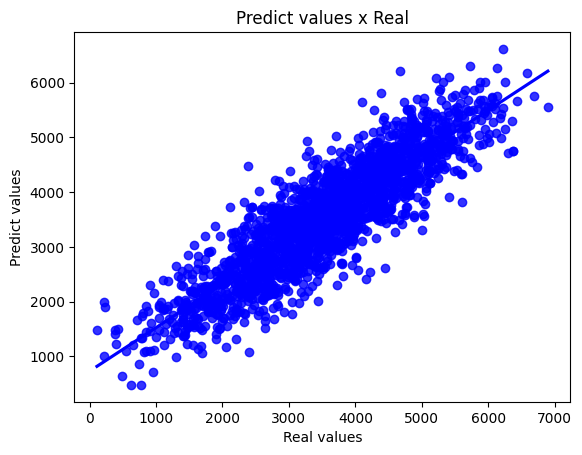

In [67]:
# Regplot to check the predict values in the real values
import matplotlib.pyplot as plt
import seaborn as sns

sns.regplot(x=y_test, y=y_pred, ci=None, color='blue')
plt.xlabel('Real values')
plt.ylabel('Predict values')
plt.title('Predict values x Real')
plt.show()

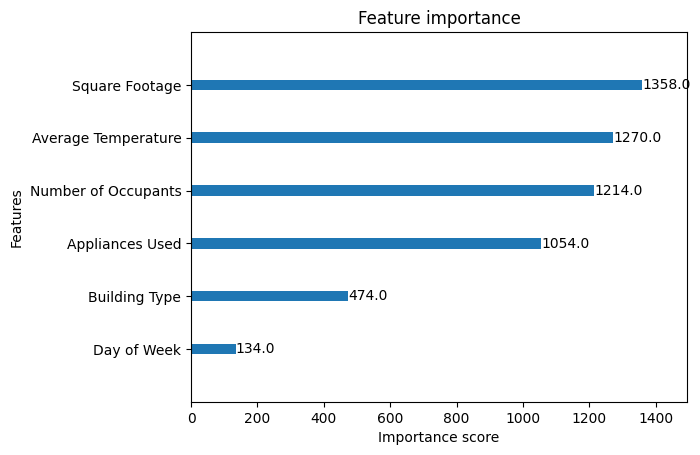

In [68]:
# Feature importance
xgb.plot_importance(model)
plt.grid(False)
plt.show()

# **Tunning the model**📈

In [69]:
# Split the train/test in matrix
dtrain = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest = xgb.DMatrix(X_test, y_test, enable_categorical=True)

In [70]:
# Import the grid search for hyperparams
from sklearn.model_selection import GridSearchCV

In [71]:
#Use the GridSearchCV looking for the best params
params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}
param_grid = GridSearchCV(estimator=model, param_grid=params, scoring='neg_mean_squared_error', cv=5, verbose=1, n_jobs=2)
param_grid.fit(X_train, y_train)
print(f'Best RMSE: {np.sqrt(abs(param_grid.best_score_))}')
print(f'Best params: {param_grid.best_params_}')

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best RMSE: 511.77919967882957
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.9}


[0]	train-rmse:1085.82261	validation-rmse:1113.13017
[100]	train-rmse:488.49693	validation-rmse:504.74823
[171]	train-rmse:481.54985	validation-rmse:503.76592


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [22:32:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()


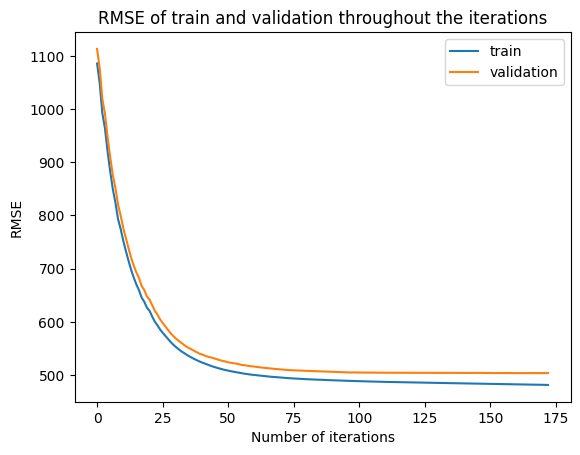

In [72]:
# View the validation and training during the boosted_rounds.
params = {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.9}

evals_result = {}

modelo = xgb.train(
   params=params,
   dtrain=dtrain,
   num_boost_round=1000,
   evals=[(dtrain, 'train'), (dtest, 'validation')],
   evals_result=evals_result,
   verbose_eval=100,
   early_stopping_rounds=10
)

train_rmse = evals_result['train']['rmse']
validation_rmse = evals_result['validation']['rmse']

plt.plot(train_rmse, label='train')
plt.plot(validation_rmse, label='validation')
plt.xlabel('Number of iterations')
plt.ylabel('RMSE')
plt.title('RMSE of train and validation throughout the iterations')
plt.legend()
plt.show()

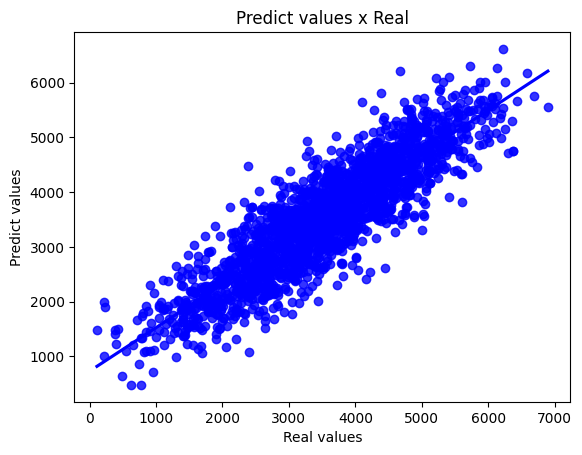

In [73]:
# Regplot to check the predict values in the real values in final model
sns.regplot(x=y_test, y=y_pred, ci=None, color='blue')
plt.xlabel('Real values')
plt.ylabel('Predict values')
plt.title('Predict values x Real')
plt.show()

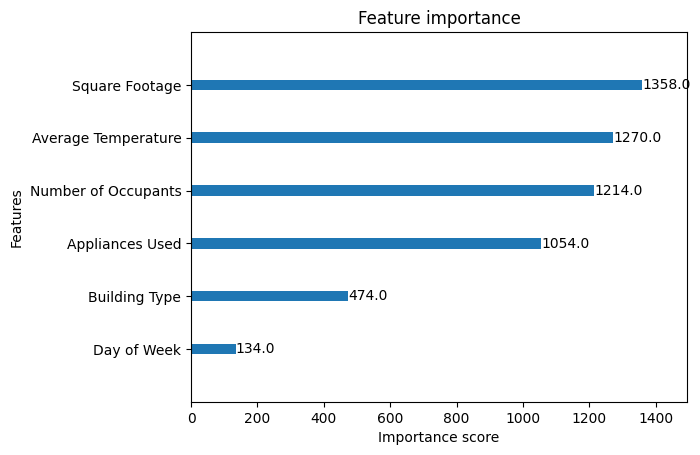

In [74]:
# Check if the feature importance changed
xgb.plot_importance(model)
plt.grid(False)
plt.show()

# **Save the model**📁

In [75]:
# Import the joblib to save the model
import joblib

In [76]:
# Save the model
model = joblib.dump(model, 'model.pkl')